## 32.5) Exercício de PyCaret para Classificação

## Meu ambiente de trabalho

In [1]:
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/pycaret-env/bin/python


In [2]:
# versão do pycaret
import pycaret
print(pycaret.__version__)

3.3.2


In [3]:
import numpy as np

from pycaret.classification import (
    setup,
    compare_models,
    create_model,
    tune_model,
    plot_model,
    evaluate_model,
    predict_model,
    finalize_model,
    save_model,
    load_model
)
from pycaret.datasets import get_data

# PyCaret para Classificação

Neste exercício, você vai escolher outra base de dados do Pycaret para repetir a pipeline de treinamento realizada em aula.

## Base de dados

In [4]:
all_bases = get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


# Observar as bases de dados para download.

Desta vez, vamos utilizar o dataset `questions`, que é um dataset de classificação com mais de duas classes.

Recupere este dataset.

In [5]:
dataset = get_data('questions')

,CAT_1_Freq,CAT_2_Freq,CAT_3_Freq,Next_Question
0,0.483696,0.391304,0.125000,1
1,0.316583,0.286432,0.396985,2
2,0.267176,0.534351,0.198473,1
3,0.521739,0.417391,0.060870,1
4,0.476923,0.446154,0.076923,1


Não existe documentação sobre este dataset, mas podemos inferir pelas colunas que, dada a frequência das categorias 1, 2 e 3, se busca inferir a categoria da próxima pergunta (`Next_Question`).

3 colunas e o next preve a questão 

Verifique quantas instâncias e quantos atributos este dataset possui.

In [6]:
print(dataset.shape)

print(f'há {dataset.shape[0]} registros e {dataset.shape[1]} colunas. ')

(499, 4)
há 499 registros e 4 colunas. 


Verifique as categorias (coluna `Next_Question`) e sua respectiva contagem.

In [7]:
np.unique(dataset['Next_Question'], return_counts=True)

(array([1, 2, 3]), array([327, 122,  50]))

### Gere uma base de treinamento correspondente a 90% dos dados totais.

In [8]:
base_train = dataset.sample(frac=0.9, random_state=1)
base_train.shape

(449, 4)

In [9]:
print(f'Na base que separamos para treino há {base_train.shape[0]} registros e {base_train.shape[1]} colunas. ')

Na base que separamos para treino há 449 registros e 4 colunas. 


## Gere a base de testes, correspondente aos dados totais que não estão presentes na base de treinamento.

In [10]:
# retirar a base de treino para achar o restante que é de teste
base_test = dataset.drop(base_train.index)
base_test.shape

(50, 4)

## Configuração do ambiente PyCaret

#### Gere um experimento, utilizando a base de treinamento. Onde o alvo é a nossa coluna 'Next_Question'

In [11]:
# informações do processo

In [12]:
experiment = setup(data=base_train, target='Next_Question', session_id=1)

,Description,Value
0,Session id,1
1,Target,Next_Question
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2"
4,Original data shape,"(449, 4)"
5,Transformed data shape,"(449, 4)"
6,Transformed train set shape,"(314, 4)"
7,Transformed test set shape,"(135, 4)"
8,Numeric features,3
9,Preprocess,True


## Treinamento de vários modelos com validação cruzada

In [13]:
models = compare_models(sort='Accuracy', fold=10) # validação cruzada fatiada por 10 fatores

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.6875,0.0000,0.6875,0.5969,0.6083,0.1878,0.2410,0.0080
lr,Logistic Regression,0.6844,0.0000,0.6844,0.5927,0.6026,0.1736,0.2308,0.3930
lda,Linear Discriminant Analysis,0.6814,0.0000,0.6814,0.5850,0.6137,0.2024,0.2389,0.0070
nb,Naive Bayes,0.6750,0.7096,0.6750,0.5885,0.6253,0.2384,0.2475,0.0080
svm,SVM - Linear Kernel,0.6565,0.0000,0.6565,0.5523,0.5724,0.1269,0.1545,0.0100
dummy,Dummy Classifier,0.6560,0.5000,0.6560,0.4305,0.5199,0.0000,0.0000,0.0050
knn,K Neighbors Classifier,0.6270,0.6256,0.6270,0.5372,0.5687,0.0900,0.1045,0.1220
gbc,Gradient Boosting Classifier,0.6237,0.0000,0.6237,0.5659,0.5834,0.1373,0.1484,0.0780
lightgbm,Light Gradient Boosting Machine,0.6175,0.6171,0.6175,0.5734,0.5906,0.1579,0.1616,80.5420
rf,Random Forest Classifier,0.6173,0.6452,0.6173,0.5721,0.5861,0.1478,0.1567,0.0510


o valor amarelo é com o melhor resultado 

## Tuning dos modelos

Pelos resultados observados, você pode ver que alguns modelos com maior acurácia têm métrica AUC igual a 0. Então, crie um modelo do tipo Naive Bayes, já que é o primeiro modelo na lista com métrica AUC alta.

In [14]:
naive_bayes = create_model('nb') #escolha o melhor modelo pelo AUC |# mesmo valor da média do AUC da seleção da validação cruzada

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7188,0.6694,0.7188,0.6571,0.6856,0.4025,0.4095
1,0.7812,0.8454,0.7812,0.7031,0.7396,0.5088,0.5242
2,0.6250,0.7031,0.6250,0.5375,0.5691,0.0791,0.0889
3,0.6250,0.6320,0.6250,0.5580,0.5891,0.1967,0.2030
4,0.5806,0.6689,0.5806,0.4516,0.5081,-0.1011,-0.1171
5,0.7742,0.8028,0.7742,0.6935,0.7312,0.4681,0.4848
6,0.6774,0.7824,0.6774,0.6059,0.6392,0.2906,0.2997
7,0.8065,0.7610,0.8065,0.7312,0.7578,0.5496,0.5933
8,0.5806,0.6454,0.5806,0.4734,0.5166,-0.0050,-0.0056


In [15]:
#parâmetro
print(naive_bayes)

GaussianNB(priors=None, var_smoothing=1e-09)


### Execute o tuning do modelo.

In [16]:
naive_bayes_tuning = tune_model(naive_bayes) # mesmo valor da média do AUC da seleção da validação cruzada

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7188,0.6694,0.7188,0.6571,0.6856,0.4025,0.4095
1,0.7812,0.8454,0.7812,0.7031,0.7396,0.5088,0.5242
2,0.6250,0.7031,0.6250,0.5375,0.5691,0.0791,0.0889
3,0.6250,0.6320,0.6250,0.5580,0.5891,0.1967,0.2030
4,0.5806,0.6689,0.5806,0.4516,0.5081,-0.1011,-0.1171
5,0.7742,0.8028,0.7742,0.6935,0.7312,0.4681,0.4848
6,0.6774,0.7824,0.6774,0.6059,0.6392,0.2906,0.2997
7,0.8065,0.7610,0.8065,0.7312,0.7578,0.5496,0.5933
8,0.5806,0.6454,0.5806,0.4734,0.5166,-0.0050,-0.0056


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [17]:
# não houve grande diferença pois o naive bayes há apenas dois parâmetros neste caso

#### Agora crie um modelo do tipo Light Gradient Boosting Machine.

In [18]:
lightgbm = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5938,0.6171,0.5938,0.5710,0.5821,0.1545,0.1549
1,0.6875,0.7520,0.6875,0.6267,0.6542,0.3059,0.3130
2,0.6562,0.6511,0.6562,0.6194,0.6280,0.2230,0.2325
3,0.6250,0.6138,0.6250,0.6003,0.6048,0.1830,0.1871
4,0.6774,0.6257,0.6774,0.6290,0.6475,0.2619,0.2697
5,0.6452,0.5895,0.6452,0.5630,0.5996,0.1345,0.1424
6,0.6129,0.5569,0.6129,0.5798,0.5948,0.1895,0.1913
7,0.6452,0.6464,0.6452,0.5963,0.6178,0.2285,0.2339
8,0.5161,0.5665,0.5161,0.4966,0.5038,-0.0022,-0.0022


Exiba os parâmetros do modelo.

In [19]:
print(lightgbm)

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=1, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [20]:
# LGBMClassifier (Light Gradient Boosting Machine):
# boosting_type='gbdt': Usa o Gradient Boosting tradicional (árvores sequenciais que corrigem erros das anteriores).
# n_estimators=100: Número de iterações de boosting (árvores).
# learning_rate=0.1: "Passo" de aprendizado; valores menores exigem mais árvores, mas melhoram a generalização.
# num_leaves=31: Máximo de folhas em uma árvore; é o principal parâmetro para controlar a complexidade.
# max_depth=-1: Sem limite de profundidade; o controle é feito pelo 'num_leaves'.
# min_child_samples=20: Número mínimo de dados em uma folha para evitar overfitting.
# n_jobs=-1: Utiliza todos os núcleos do processador para treinamento paralelo.
# Diferença fundamental: Cresce as árvores de forma vertical (leaf-wise), sendo mais rápido que o XGBoost tradicional.

#model_lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31, random_state=1, n_jobs=-1)

In [21]:
# LGBMClassifier: modelo de Gradient Boosting otimizado (LightGBM)

# LGBMClassifier(
#     boosting_type='gbdt',        # Tipo de boosting (gbdt = Gradient Boosting Decision Tree)
#     class_weight=None,           # Peso das classes (None = classes balanceadas automaticamente)
#     colsample_bytree=1.0,         # Fração de features usadas por árvore (1.0 = todas)
#     importance_type='split',      # Importância das features baseada em nº de splits
#     learning_rate=0.1,            # Taxa de aprendizado (quanto cada árvore contribui)
#     max_depth=-1,                 # Profundidade máxima da árvore (-1 = sem limite)
#     min_child_samples=20,         # Nº mínimo de amostras por folha
#     min_child_weight=0.001,       # Peso mínimo de uma folha (regularização)
#     min_split_gain=0.0,           # Ganho mínimo para permitir um split
#     n_estimators=100,             # Número de árvores (iterações do boosting)
#     n_jobs=-1,                    # Usa todos os núcleos da CPU
#     num_leaves=31,                # Nº máximo de folhas por árvore (controla complexidade)
#     objective=None,               # Função objetivo (None = inferida automaticamente)
#     random_state=1,               # Semente para reprodutibilidade
#     reg_alpha=0.0,                # Regularização L1
#     reg_lambda=0.0,               # Regularização L2
#     subsample=1.0,                # Fração de dados usada por árvore (1.0 = todos)
#     subsample_for_bin=200000,     # Nº de amostras usadas para criar os bins
#     subsample_freq=0              # Frequência do subsample (0 = desativado)
# )


Faça o tuning do modelo, investindo o número de estimadores (`n_estimators`) no intervalo 50 a 100, com passos de 10.

In [22]:
lightgbm_tuning = tune_model(lightgbm, custom_grid = {'n_neighbors' : np.arange(50, 101, 10)}) # tive que parar, muito extenso

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,20:30:13
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Light Gradient Boosting Machine


Fitting 10 folds for each of 6 candidates, totalling 60 fits
[LightGBM] [Warning] Unknown parameter: n_neighbors
[LightGBM] [Warning] Unknown parameter: n_neighbors
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.298395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 283
[LightGBM] [Info] Number of data points in the train set: 282, number of used features: 3
[LightGBM] [Info] Start training from score -0.421551
[LightGBM] [Info] Start training from score -1.407801
[LightGBM] [Info] Start training from score -2.309703
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

KeyboardInterrupt: 

## tuning para achar o melhor parâmetro

Exiba os parâmetros do modelo ajustado.

In [ ]:
lightgbm_tuning = tune_model(lightgbm, custom_grid = {'n_neighbors' : np.arange(2, 5, 2)}) # tive que parar, muito extenso

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,22:36:04
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Light Gradient Boosting Machine


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 2 candidates, totalling 20 fits


In [ ]:
print(lightgbm_tuning)

## Gráficos

Exiba um gráfico da matriz de confusão do modelo Naive Bayes ajustado por tuning de parâmetros.


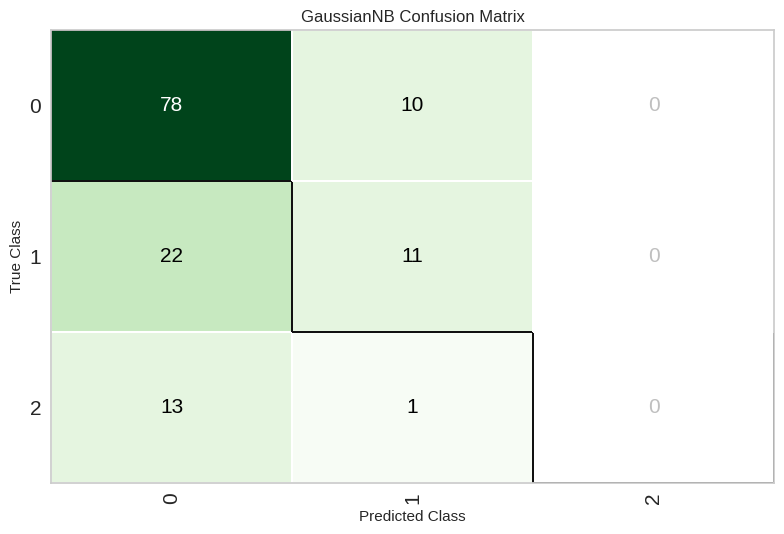

In [26]:
plot_model(naive_bayes_tuning, plot='confusion_matrix')

Agora exiba um gráfico do reporte por classe.

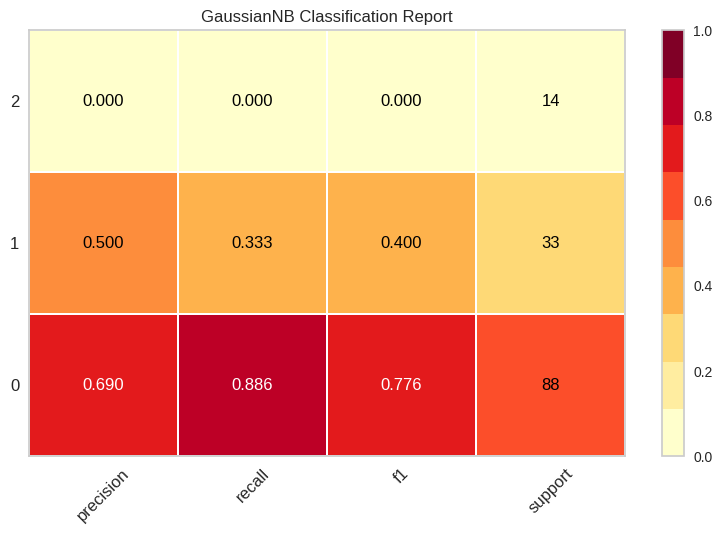

In [27]:
plot_model(naive_bayes_tuning, plot='class_report')

Exiba um gráfico do tipo fronteira (boundary).

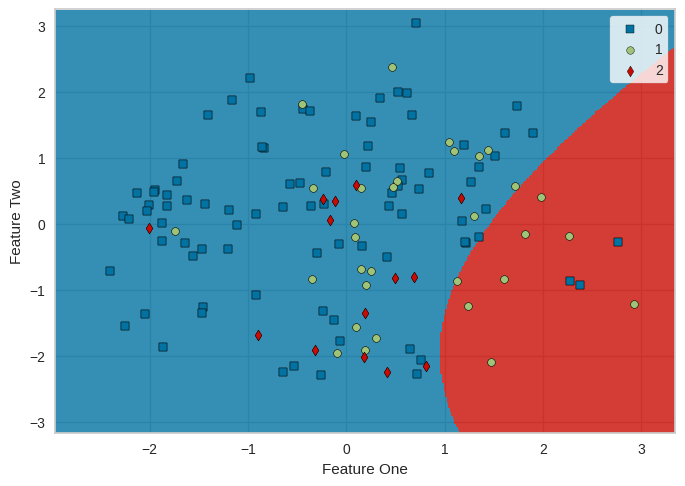

In [28]:
plot_model(naive_bayes_tuning, plot='boundary')

Exiba um gráfico com os erros do algoritmo.

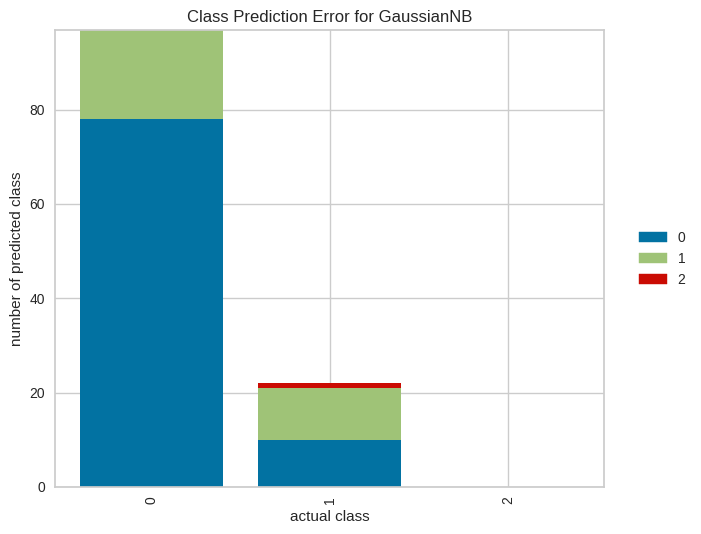

In [29]:
plot_model(naive_bayes_tuning, plot='error')

#### Exiba a avaliação do modelo.

In [30]:
evaluate_model(naive_bayes_tuning)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

## Previsões com o modelo

Execute as previsões do modelo.

In [31]:
predict_model(naive_bayes_tuning);

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,0.6593,0,0.6593,0.5722,0.6037,0.1780,0.1989


Crie uma versão final do modelo ajustado por tuning de hiperparâmetros.

In [32]:
naive_bayes_final = finalize_model(naive_bayes_tuning)
print(naive_bayes_final)

Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['CAT_1_Freq', 'CAT_2_Freq',
                                             'CAT_3_Freq'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),
                ('categorical_imputer',
                 Transfor

Salve este modelo.

In [33]:
save_model(naive_bayes_final, 'exercicio_naive_bayes')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['CAT_1_Freq', 'CAT_2_Freq',
                                              'CAT_3_Freq'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
          

## Recarregue o modelo salvo.

In [34]:
naive_bayes_loaded = load_model('exercicio_naive_bayes')

Transformation Pipeline and Model Successfully Loaded


Faça previsões com o modelo recarregado na base de testes.

In [35]:
prevision = predict_model(naive_bayes_loaded, data=base_test)
prevision

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,0.6600,0,0.6600,0.5829,0.6177,0.2137,0.2238


,CAT_1_Freq,CAT_2_Freq,CAT_3_Freq,Next_Question,prediction_label,prediction_score
1,0.316583,0.286432,0.396985,2,1,0.5291
7,0.007519,0.353383,0.639098,2,2,0.4579
22,0.460396,0.277228,0.262376,1,1,0.7686
37,0.213483,0.230337,0.556180,2,2,0.4954
50,0.149171,0.303867,0.546961,1,2,0.4009
68,0.113772,0.311377,0.574850,3,2,0.4184
71,0.317829,0.360465,0.321705,3,1,0.6658
72,0.050000,0.490000,0.460000,3,1,0.5027
86,0.323944,0.640845,0.035211,1,1,0.9716
115,0.412500,0.137500,0.450000,2,2,0.4778
